# Step 6 - Seasonality Analysis

This notebook measures the repeating seasonal structure in PJM East hourly demand. The main questions are which cycle is strongest, whether the transformed series still retains interpretable seasonality, and which seasonal period should drive the SARIMA specification.


In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.tsa.seasonal import STL

PROCESSED_PATH = "../data/processed/"
FIGURES_PATH = "../reports/figures/"

os.makedirs(FIGURES_PATH, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

raw_series = pd.read_csv(
    os.path.join(PROCESSED_PATH, "pjme_imputed.csv"),
    parse_dates=["Datetime"],
    index_col="Datetime",
)["PJME_MW"].astype(float)

transformed_series = pd.read_csv(
    os.path.join(PROCESSED_PATH, "pjme_transformed.csv"),
    parse_dates=["Datetime"],
    index_col="Datetime",
)["PJME_MW_transformed"].astype(float)

print(f"Raw series length: {len(raw_series):,}")
print(f"Transformed series length: {len(transformed_series):,}")
raw_series.head()


Raw series length: 145,392
Transformed series length: 145,367


Datetime
2002-01-01 01:00:00    30393.0
2002-01-01 02:00:00    29265.0
2002-01-01 03:00:00    28357.0
2002-01-01 04:00:00    27899.0
2002-01-01 05:00:00    28057.0
Name: PJME_MW, dtype: float64

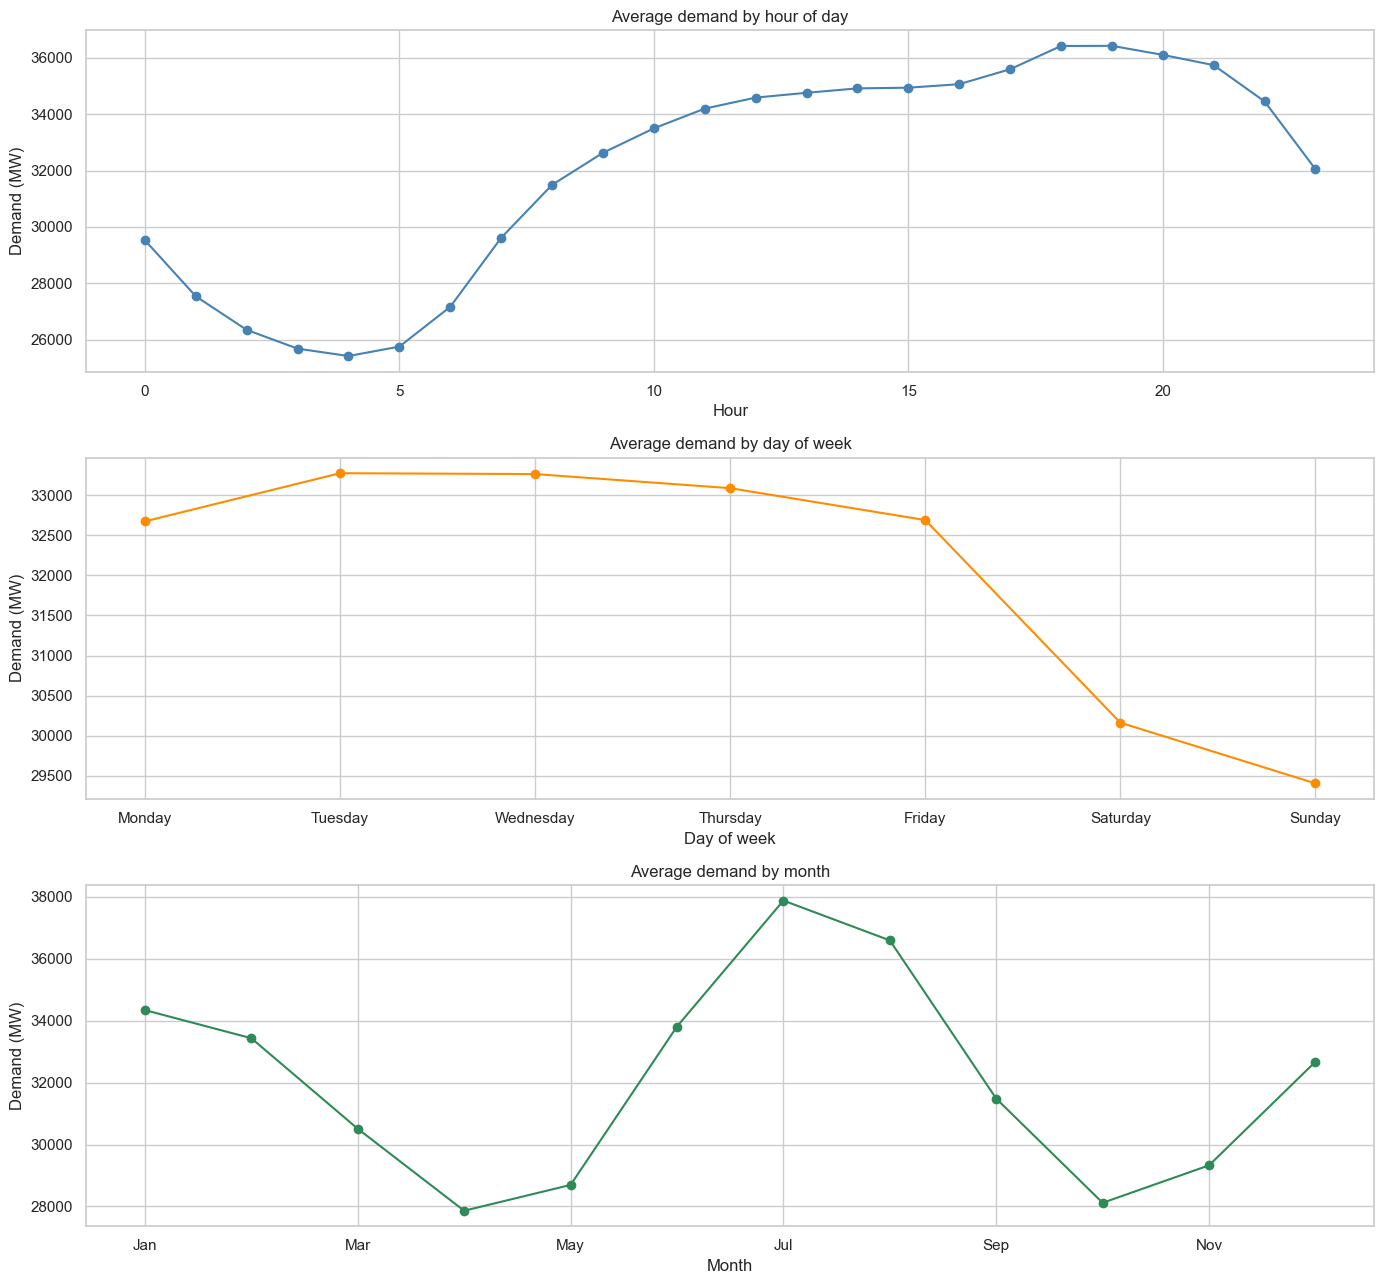

In [3]:
seasonal_profile = pd.DataFrame({"PJME_MW": raw_series})
seasonal_profile["hour"] = seasonal_profile.index.hour
seasonal_profile["day_of_week"] = seasonal_profile.index.day_name()
seasonal_profile["month"] = seasonal_profile.index.month_name().str.slice(0, 3)

hour_profile = seasonal_profile.groupby("hour")["PJME_MW"].mean()
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
day_profile = (
    seasonal_profile.groupby("day_of_week")["PJME_MW"].mean().reindex(day_order)
)
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_profile = seasonal_profile.groupby("month")["PJME_MW"].mean().reindex(month_order)

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

hour_profile.plot(ax=axes[0], color="steelblue", marker="o")
axes[0].set_title("Average demand by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Demand (MW)")

day_profile.plot(ax=axes[1], color="darkorange", marker="o")
axes[1].set_title("Average demand by day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Demand (MW)")

month_profile.plot(ax=axes[2], color="seagreen", marker="o")
axes[2].set_title("Average demand by month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Demand (MW)")

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "06_seasonal_profiles.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()


These profiles should make the seasonal hierarchy visible immediately. The hourly profile captures the strongest repeating cycle, the weekday profile shows operational differences between business days and weekends, and the monthly profile reflects the broader heating and cooling demand pattern.


In [4]:
seasonal_lag_summary = pd.DataFrame(
    [
        {"series": "raw", "lag": 1, "autocorrelation": raw_series.autocorr(1)},
        {"series": "raw", "lag": 24, "autocorrelation": raw_series.autocorr(24)},
        {"series": "raw", "lag": 168, "autocorrelation": raw_series.autocorr(168)},
        {"series": "transformed", "lag": 1, "autocorrelation": transformed_series.autocorr(1)},
        {"series": "transformed", "lag": 24, "autocorrelation": transformed_series.autocorr(24)},
        {"series": "transformed", "lag": 168, "autocorrelation": transformed_series.autocorr(168)},
    ]
)

display(seasonal_lag_summary.style.format({"autocorrelation": "{:,.4f}"}))


,series,lag,autocorrelation
0,raw,1,0.9748
1,raw,24,0.8914
2,raw,168,0.7825
3,transformed,1,0.6781
4,transformed,24,-0.1405
5,transformed,168,0.5504


The raw series usually shows very high autocorrelation at both 24 and 168 hours, confirming daily and weekly dependence. After differencing, those spikes should shrink sharply, but they are still useful as evidence that the original model needs an explicit seasonal component instead of a purely non-seasonal ARIMA structure.


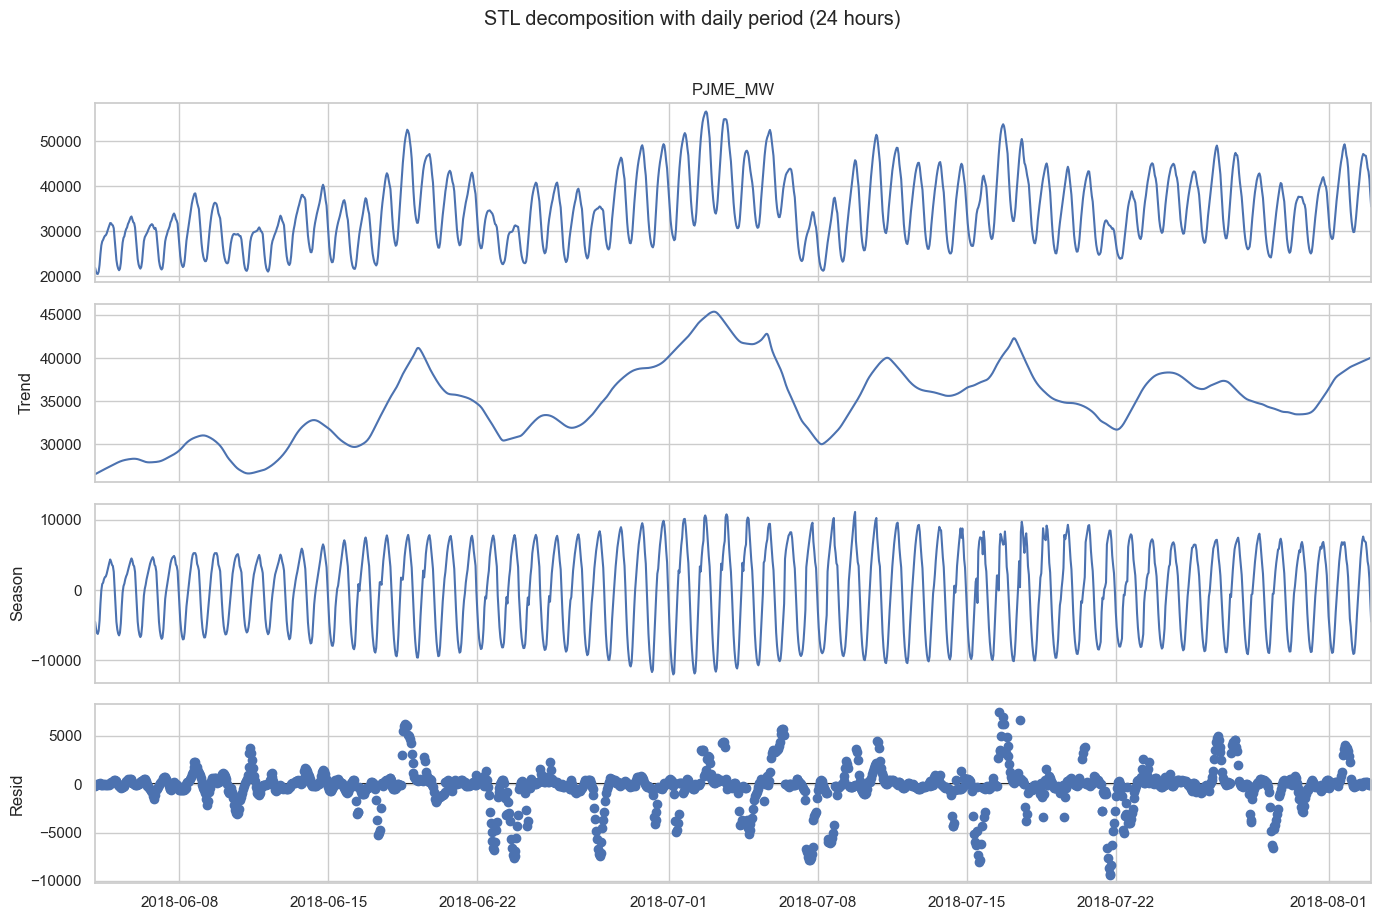

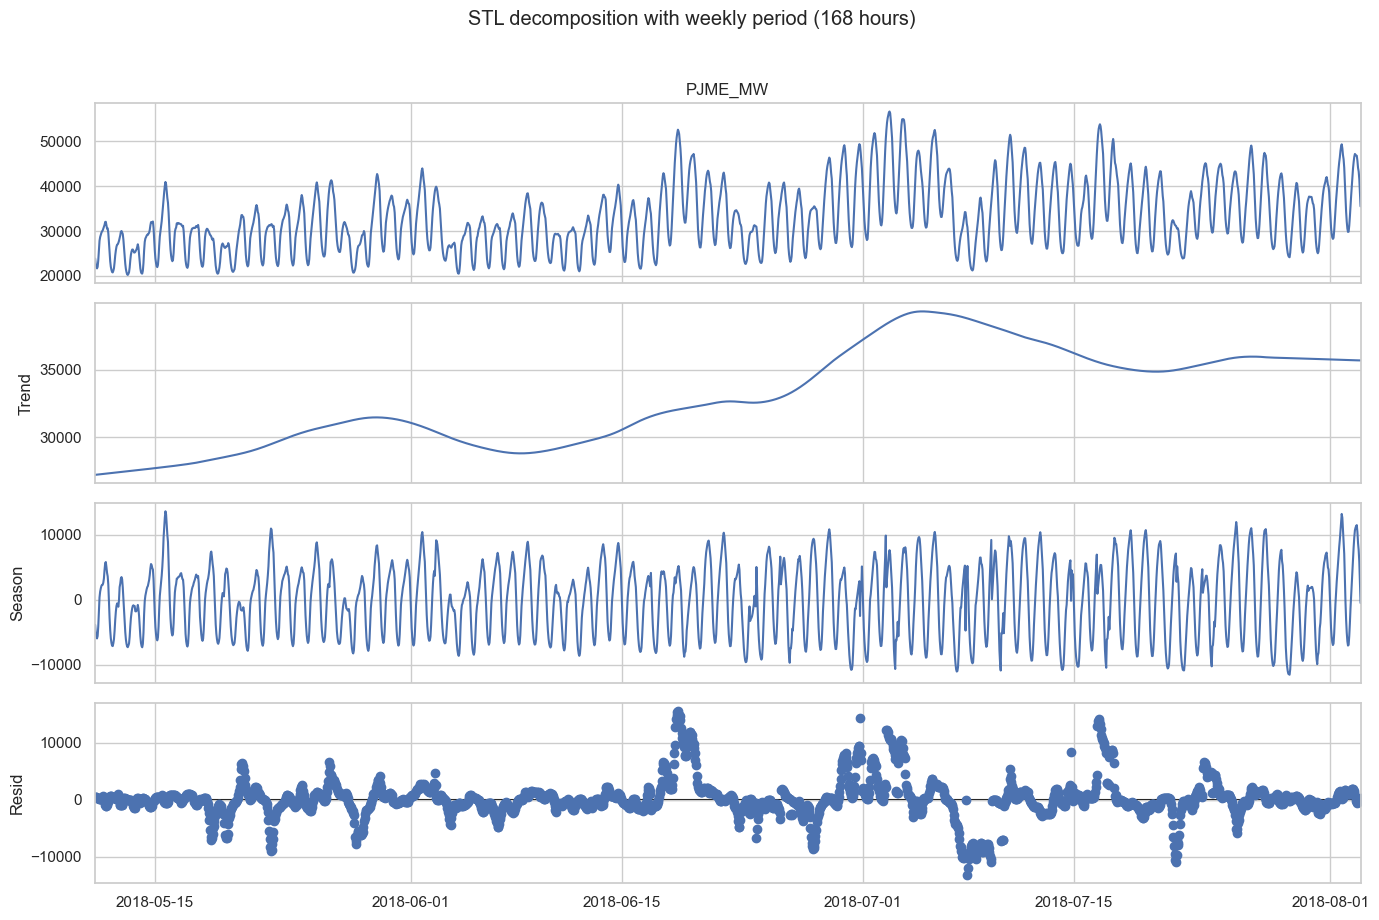

In [5]:
daily_window = raw_series.iloc[-24 * 60 :]
weekly_window = raw_series.iloc[-24 * 7 * 12 :]

daily_stl = STL(daily_window, period=24, robust=True).fit()
weekly_stl = STL(weekly_window, period=24 * 7, robust=True).fit()

fig_daily = daily_stl.plot()
fig_daily.set_size_inches(14, 9)
fig_daily.suptitle("STL decomposition with daily period (24 hours)", y=1.02)
fig_daily.tight_layout()
fig_daily.savefig(
    os.path.join(FIGURES_PATH, "06_stl_daily.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

fig_weekly = weekly_stl.plot()
fig_weekly.set_size_inches(14, 9)
fig_weekly.suptitle("STL decomposition with weekly period (168 hours)", y=1.02)
fig_weekly.tight_layout()
fig_weekly.savefig(
    os.path.join(FIGURES_PATH, "06_stl_weekly.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()


The decompositions help separate the strongest repeating signals from the remainder term. In this dataset the 24-hour cycle is the most natural primary seasonal period for SARIMA, while the weekly effect remains important context for diagnostics and forecast evaluation.


In [6]:
seasonality_summary = pd.DataFrame(
    [
        {
            "recommended_primary_seasonal_period": 24,
            "secondary_cycle_observed_hours": 168,
            "hourly_profile_range_mw": hour_profile.max() - hour_profile.min(),
            "weekday_profile_range_mw": day_profile.max() - day_profile.min(),
            "monthly_profile_range_mw": month_profile.max() - month_profile.min(),
            "raw_autocorr_lag_24": raw_series.autocorr(24),
            "raw_autocorr_lag_168": raw_series.autocorr(168),
        }
    ]
)

seasonality_summary.to_csv(
    os.path.join(PROCESSED_PATH, "seasonality_summary.csv"), index=False
)

print("Saved seasonality summary to ../data/processed/seasonality_summary.csv")
seasonality_summary


Saved seasonality summary to ../data/processed/seasonality_summary.csv


,recommended_primary_seasonal_period,secondary_cycle_observed_hours,hourly_profile_range_mw,weekday_profile_range_mw,monthly_profile_range_mw,raw_autocorr_lag_24,raw_autocorr_lag_168
0,24,168,11011.705183,3865.676464,10020.47476,0.89141,0.782457


Final decision: model the series with a primary seasonal period of 24 hours and treat the 168-hour weekly cycle as a secondary pattern to check through residual diagnostics and candidate comparison. This keeps the SARIMA search practical without ignoring the weekly structure revealed in the data.
